# CS3807 – Deep Learning Laboratory
## Experiment 7 — Complete Autoencoder Study

### Models
1. Fully Connected Autoencoder
2. Convolutional Autoencoder
3. Denoising Convolutional Autoencoder
4. Variational Autoencoder

### Dataset
MNIST — controlled laboratory protocol:
- 10,000-image training pool
- 2,000 held-out test images
- image size 28 × 28 × 1
- normalized to [0,1]

This notebook contains the mandatory experiment AND all eight Additional Exercises listed in the laboratory sheet.

**Important:** Numerical results are generated only after execution. No performance value is hard-coded.

## Complete coverage map

Mandatory work:
- FC-AE implementation and reconstruction
- FC-AE training/validation loss
- MSE, MAE, SSIM
- CAE implementation
- FC-AE vs CAE comparison
- Gaussian denoising at σ = 0.1, 0.2, 0.3
- salt-and-pepper corruption at p = 0.05, 0.10, 0.20
- denoising visual analysis
- VAE with z ∈ R²
- μ, log σ² and reparameterization
- reconstruction + KL losses
- VAE latent-space visualization
- 25 generated images
- latent interpolation
- VAE reconstruction-loss curves
- reconstruction-error distribution
- five highest-error samples
- consolidated comparison
- latent dimension study z = 2, 8, 16, 32
- all mandatory discussion questions

Additional Exercises:
1. CAE latent dimensions 4, 8, 16, 32
2. Gaussian vs salt-and-pepper using the same denoising architecture
3. Two noise levels compared using SSIM
4. UpSampling decoder vs Conv2DTranspose decoder
5. VAE latent dimensions 2 and 8
6. KL-loss contribution study
7. Larger VAE generated grid
8. Latent-region interpolation

The source specification explicitly lists these additional exercises. fileciteturn0file0L498-L506

In [ ]:
# ============================================================
# 0. ENVIRONMENT, REPRODUCIBILITY AND MEMORY SAFETY
# ============================================================
import os, gc, json, time, random, warnings, shutil
from pathlib import Path

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

ROOT = Path("/content/Experiment_7_Autoencoders_COMPLETE")
EPS_DIR = ROOT / "plots_eps_600dpi"
PNG_DIR = ROOT / "plots_png_preview"
CKPT_DIR = ROOT / "checkpoints"
TABLE_DIR = ROOT / "tables"
LOG_DIR = ROOT / "logs"
METRIC_DIR = ROOT / "metrics"

for d in [EPS_DIR, PNG_DIR, CKPT_DIR, TABLE_DIR, LOG_DIR, METRIC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output directory:", ROOT)

def clean_memory():
    tf.keras.backend.clear_session()
    gc.collect()

BATCH = 128

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Output directory: /content/Experiment_7_Autoencoders_COMPLETE


In [ ]:
# ============================================================
# 1. TIMES NEW ROMAN + 14 PT + BOLD AXES / LEGENDS
# ============================================================
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

tnr = [f.name for f in font_manager.fontManager.ttflist
       if f.name.lower() == "times new roman"]

rcParams["font.family"] = "Times New Roman"
rcParams["font.size"] = 14
rcParams["axes.titlesize"] = 14
rcParams["axes.labelsize"] = 14
rcParams["xtick.labelsize"] = 14
rcParams["ytick.labelsize"] = 14
rcParams["legend.fontsize"] = 14

print("Times New Roman detected:", bool(tnr))
if not tnr:
    print("WARNING: install/upload Times New Roman in Colab before final EPS export.")

def finish_axes(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold")
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontsize(14)
        t.set_fontweight("bold")
    leg = ax.get_legend()
    if leg:
        for t in leg.get_texts():
            t.set_fontsize(14)
            t.set_fontweight("bold")

def savefig(fig, name):
    eps = EPS_DIR / f"{name}.eps"
    png = PNG_DIR / f"{name}.png"
    fig.savefig(eps, format="eps", dpi=600, bbox_inches="tight")
    fig.savefig(png, format="png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return eps

Times New Roman detected: False


In [ ]:
# ============================================================
# 2. MNIST DATA — 10,000 TRAINING POOL + 2,000 HELD-OUT TEST
# ============================================================
from tensorflow.keras.datasets import mnist

(x_full, y_full), (x_test_raw, y_test) = mnist.load_data()

x_pool = x_full[:10000].astype("float32") / 255.0
y_pool = y_full[:10000]
x_test = x_test_raw[:2000].astype("float32") / 255.0
y_test = y_test[:2000]

# 20% validation from the training pool; test remains unseen.
VAL_N = 2000
x_val = x_pool[-VAL_N:]
y_val = y_pool[-VAL_N:]
x_train = x_pool[:-VAL_N]
y_train = y_pool[:-VAL_N]

x_train_img = x_train[..., None]
x_val_img = x_val[..., None]
x_test_img = x_test[..., None]

x_train_flat = x_train.reshape(-1, 784)
x_val_flat = x_val.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Training:", x_train_img.shape)
print("Validation:", x_val_img.shape)
print("Held-out test:", x_test_img.shape)
print("Range:", x_train_img.min(), x_train_img.max())

del x_full, y_full, x_test_raw
gc.collect()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training: (8000, 28, 28, 1)
Validation: (2000, 28, 28, 1)
Held-out test: (2000, 28, 28, 1)
Range: 0.0 1.0


57

In [ ]:
# ============================================================
# 3. COMMON METRICS / PREDICTION UTILITIES
# ============================================================
from skimage.metrics import structural_similarity as structural_ssim
import pandas as pd

def predict_batched(model, x):
    return model.predict(x, batch_size=128, verbose=0)

def metrics_image(x_true, x_pred):
    mse = float(np.mean((x_true - x_pred)**2))
    mae = float(np.mean(np.abs(x_true - x_pred)))
    vals = [
        structural_ssim(np.squeeze(a), np.squeeze(b), data_range=1.0)
        for a, b in zip(x_true, x_pred)
    ]
    return {"MSE": mse, "MAE": mae, "SSIM": float(np.mean(vals))}

def image_errors(x_true, x_pred):
    return np.mean((x_true - x_pred)**2, axis=(1,2,3))

def add_ckpt_callbacks(path, csv_name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            str(path), monitor="val_loss",
            save_best_only=True, save_weights_only=True, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.CSVLogger(str(LOG_DIR / csv_name), append=True)
    ]

# 4. FULLY CONNECTED AUTOENCODER

Required architecture from the sheet:

**784 → 128 → 32 → 16 → 32 → 128 → 784**

Hidden layers use ReLU; output uses sigmoid. The specified configuration is latent dimension 16, Adam, learning rate 10⁻³, batch size 128, 20 epochs and binary cross-entropy. fileciteturn0file0L119-L146

In [ ]:
# ============================================================
# 4A. FC-AE
# ============================================================
from tensorflow.keras import layers, Model

def build_fc_ae(latent_dim=16):
    inp = layers.Input((784,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(784, activation="sigmoid")(x)
    return Model(inp, out, name=f"FC_AE_z{latent_dim}")

fc_ae = build_fc_ae(16)
fc_ae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)
fc_ae.summary()

fc_path = CKPT_DIR / "fc_ae_best.weights.h5"
t0 = time.time()
fc_hist = fc_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_val_flat, x_val_flat),
    epochs=20, batch_size=128,
    callbacks=add_ckpt_callbacks(fc_path, "fc_ae.csv"),
    verbose=1
)
fc_time = time.time() - t0
fc_ae.load_weights(fc_path)

fc_pred = predict_batched(fc_ae, x_test_flat).reshape(-1,28,28,1)
fc_metrics = metrics_image(x_test_img, fc_pred)
print(fc_metrics, "time:", fc_time)

Model: "FC_AE_z16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4971
Epoch 1: val_loss improved from None to 0.25502, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_ae_best.weights.h5

Epoch 1: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_ae_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.3654 - val_loss: 0.2550
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2439
Epoch 2: val_loss improved from 0.25502 to 0.22346, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_ae_best.weights.h5

Epoch 2: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_ae_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2355 - val_loss: 0.2235
Epoch 3/20
58/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2142
Epoch 3: val_loss improved from 0.22346 to 0.19363, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_ae_best.weights

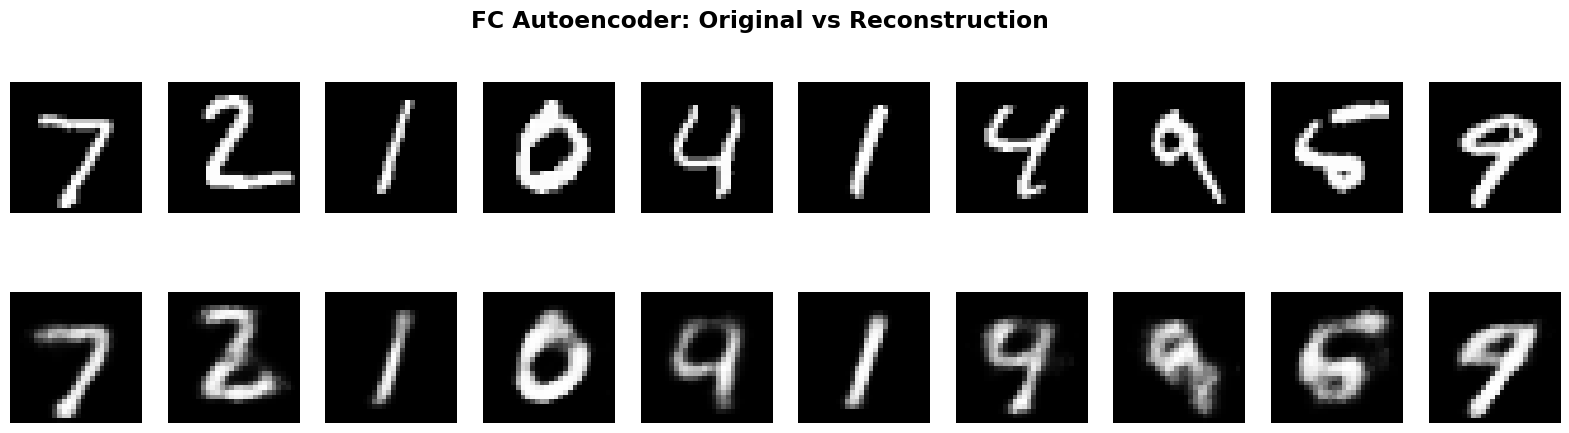

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/01_fc_original_reconstruction.eps')

In [ ]:
# ============================================================
# 4B. PLOT — ORIGINAL VS FC-AE RECONSTRUCTION
# ============================================================
n = 10
fig, ax = plt.subplots(2,n,figsize=(20,5))
for i in range(n):
    ax[0,i].imshow(x_test[i], cmap="gray")
    ax[1,i].imshow(fc_pred[i].squeeze(), cmap="gray")
    ax[0,i].axis("off"); ax[1,i].axis("off")
ax[0,0].set_ylabel("Original", fontweight="bold")
ax[1,0].set_ylabel("Reconstruction", fontweight="bold")
fig.suptitle("FC Autoencoder: Original vs Reconstruction", fontweight="bold")
savefig(fig,"01_fc_original_reconstruction")

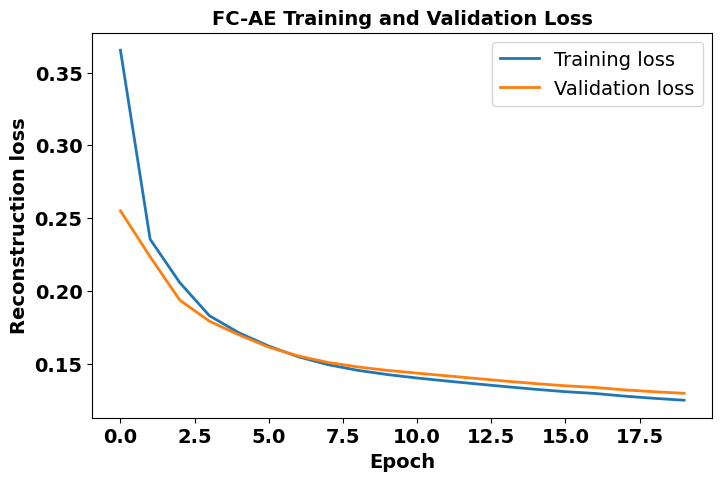

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/02_fc_training_validation_loss.eps')

In [ ]:
# ============================================================
# 4C. PLOT — TRAINING / VALIDATION RECONSTRUCTION LOSS
# ============================================================
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(fc_hist.history["loss"], label="Training loss", linewidth=2)
ax.plot(fc_hist.history["val_loss"], label="Validation loss", linewidth=2)
finish_axes(ax, "FC-AE Training and Validation Loss", "Epoch", "Reconstruction loss")
ax.legend()
savefig(fig,"02_fc_training_validation_loss")

# 5. CONVOLUTIONAL AUTOENCODER

The suggested CAE architecture in the sheet uses:
Conv2D(32) → MaxPooling2D → Conv2D(64) → MaxPooling2D → Conv2D(64) → UpSampling2D → Conv2D(32) → UpSampling2D → Conv2D(1). fileciteturn0file0L194-L217

In [ ]:
# ============================================================
# 5A. CAE
# ============================================================
def build_cae(transposed=False):
    inp = layers.Input((28,28,1))
    x = layers.Conv2D(32,3,activation="relu",padding="same")(inp)
    x = layers.MaxPooling2D(2,padding="same")(x)
    x = layers.Conv2D(64,3,activation="relu",padding="same")(x)
    x = layers.MaxPooling2D(2,padding="same")(x)
    x = layers.Conv2D(64,3,activation="relu",padding="same")(x)

    if not transposed:
        x = layers.UpSampling2D(2)(x)
        x = layers.Conv2D(32,3,activation="relu",padding="same")(x)
        x = layers.UpSampling2D(2)(x)
        out = layers.Conv2D(1,3,activation="sigmoid",padding="same")(x)
    else:
        x = layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
        x = layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)
        out = layers.Conv2D(1,3,activation="sigmoid",padding="same")(x)

    return Model(inp,out,name="CAE_Transpose" if transposed else "CAE_UpSampling")

cae = build_cae(False)
cae.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss="binary_crossentropy")

cae_path = CKPT_DIR/"cae_best.weights.h5"
t0=time.time()
cae_hist=cae.fit(
    x_train_img,x_train_img,
    validation_data=(x_val_img,x_val_img),
    epochs=20,batch_size=128,
    callbacks=add_ckpt_callbacks(cae_path,"cae.csv"),
    verbose=1
)
cae_time=time.time()-t0
cae.load_weights(cae_path)
cae_pred=predict_batched(cae,x_test_img)
cae_metrics=metrics_image(x_test_img,cae_pred)
print(cae_metrics,"time:",cae_time)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4391
Epoch 1: val_loss improved from None to 0.12020, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_best.weights.h5

Epoch 1: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - loss: 0.2797 - val_loss: 0.1202
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1082
Epoch 2: val_loss improved from 0.12020 to 0.09135, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_best.weights.h5

Epoch 2: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1001 - val_loss: 0.0914
Epoch 3/20
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0887
Epoch 3: val_loss improved from 0.09135 to 0.08337, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_best.weights.h5

Epoch

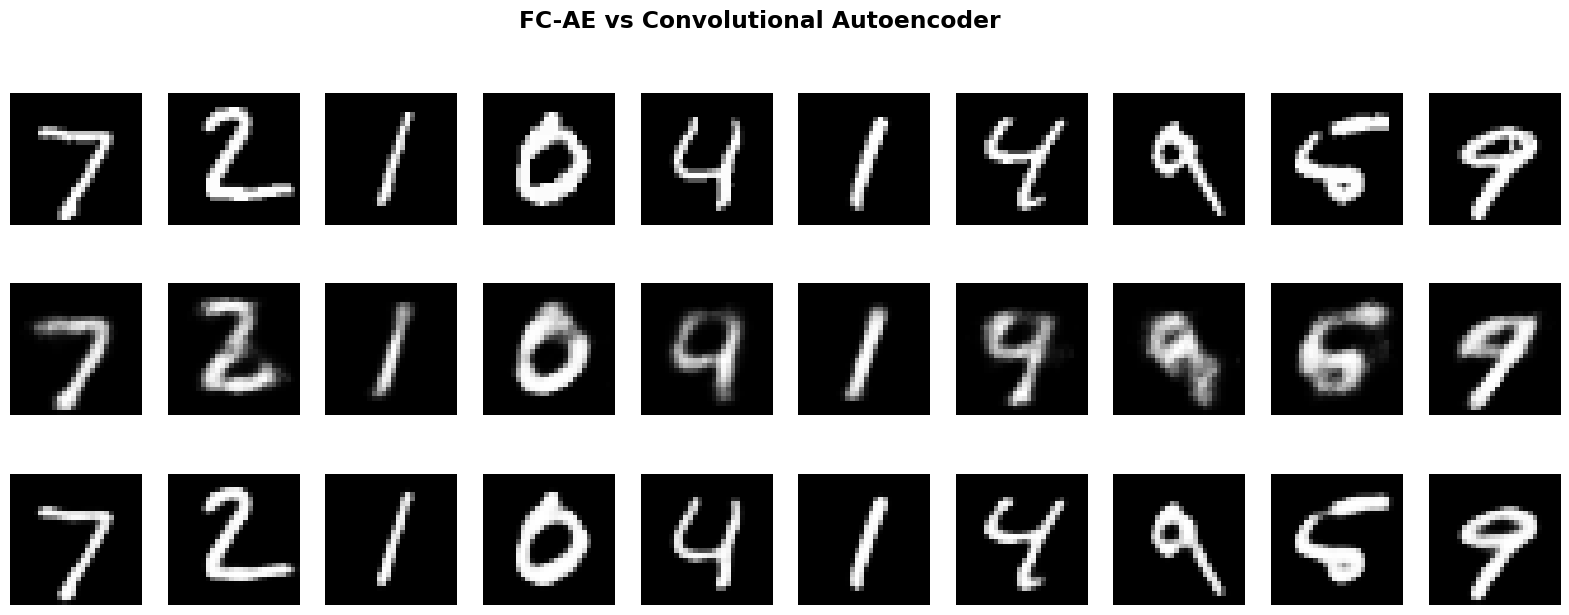

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/03_fc_vs_cae.eps')

In [ ]:
# ============================================================
# 5B. PLOT — FC VS CAE
# ============================================================
fig,ax=plt.subplots(3,n,figsize=(20,7))
for i in range(n):
    ax[0,i].imshow(x_test[i],cmap="gray")
    ax[1,i].imshow(fc_pred[i].squeeze(),cmap="gray")
    ax[2,i].imshow(cae_pred[i].squeeze(),cmap="gray")
    for r in range(3): ax[r,i].axis("off")
ax[0,0].set_ylabel("Original",fontweight="bold")
ax[1,0].set_ylabel("FC-AE",fontweight="bold")
ax[2,0].set_ylabel("CAE",fontweight="bold")
fig.suptitle("FC-AE vs Convolutional Autoencoder",fontweight="bold")
savefig(fig,"03_fc_vs_cae")

# 6. DENOISING AUTOENCODER

The specification requires at least two corruption types. Gaussian noise uses σ ∈ {0.1, 0.2, 0.3}; salt-and-pepper uses p ∈ {0.05, 0.10, 0.20}. fileciteturn0file0L230-L253

In [ ]:
# ============================================================
# 6A. NOISE FUNCTIONS
# ============================================================
def gaussian_noise(x,sigma,seed=42):
    rng=np.random.default_rng(seed)
    return np.clip(x+rng.normal(0,sigma,x.shape),0,1).astype("float32")

def salt_pepper(x,p,seed=42):
    rng=np.random.default_rng(seed)
    y=x.copy()
    r=rng.random(x.shape)
    y[r<p/2]=0
    y[(r>=p/2)&(r<p)]=1
    return y.astype("float32")

G_LEVELS=[0.1,0.2,0.3]
SP_LEVELS=[0.05,0.10,0.20]

In [ ]:
# ============================================================
# 6B. TRAIN GAUSSIAN DENOISER
# ============================================================
gtrain=np.concatenate([gaussian_noise(x_train_img,s,42+i) for i,s in enumerate(G_LEVELS)])
gtarget=np.concatenate([x_train_img]*len(G_LEVELS))

denoise_g=build_cae(False)
denoise_g.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss="binary_crossentropy")
p=CKPT_DIR/"denoise_gaussian_best.weights.h5"

t0=time.time()
h=denoise_g.fit(
    gtrain,gtarget,
    validation_data=(gaussian_noise(x_val_img,0.2,100),x_val_img),
    epochs=20,batch_size=128,
    callbacks=add_ckpt_callbacks(p,"denoise_gaussian.csv"),
    verbose=1
)
g_time=time.time()-t0
denoise_g.load_weights(p)

del gtrain,gtarget
gc.collect()

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2821
Epoch 1: val_loss improved from None to 0.09266, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_gaussian_best.weights.h5

Epoch 1: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_gaussian_best.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.1660 - val_loss: 0.0927
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0916
Epoch 2: val_loss improved from 0.09266 to 0.08392, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_gaussian_best.weights.h5

Epoch 2: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_gaussian_best.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0895 - val_loss: 0.0839
Epoch 3/20
183/188 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0845
Epoch 3: val_loss improved from 0.08392 to 0.08031, saving model to /content/Experiment_

35672

In [ ]:
# ============================================================
# 6C. TRAIN SALT-AND-PEPPER DENOISER — SAME ARCHITECTURE
# ============================================================
sptrain=np.concatenate([salt_pepper(x_train_img,p,100+i) for i,p in enumerate(SP_LEVELS)])
sptarget=np.concatenate([x_train_img]*len(SP_LEVELS))

denoise_sp=build_cae(False)
denoise_sp.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss="binary_crossentropy")
p=CKPT_DIR/"denoise_sp_best.weights.h5"

t0=time.time()
hsp=denoise_sp.fit(
    sptrain,sptarget,
    validation_data=(salt_pepper(x_val_img,0.10,200),x_val_img),
    epochs=20,batch_size=128,
    callbacks=add_ckpt_callbacks(p,"denoise_sp.csv"),
    verbose=1
)
sp_time=time.time()-t0
denoise_sp.load_weights(p)

del sptrain,sptarget
gc.collect()

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2749
Epoch 1: val_loss improved from None to 0.09337, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_sp_best.weights.h5

Epoch 1: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_sp_best.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.1668 - val_loss: 0.0934
Epoch 2/20
184/188 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0934
Epoch 2: val_loss improved from 0.09337 to 0.08516, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_sp_best.weights.h5

Epoch 2: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/denoise_sp_best.weights.h5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0913 - val_loss: 0.0852
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0869
Epoch 3: val_loss improved from 0.08516 to 0.08184, saving model to /content/Experiment_7_Autoencoders_COMPLETE/

2810

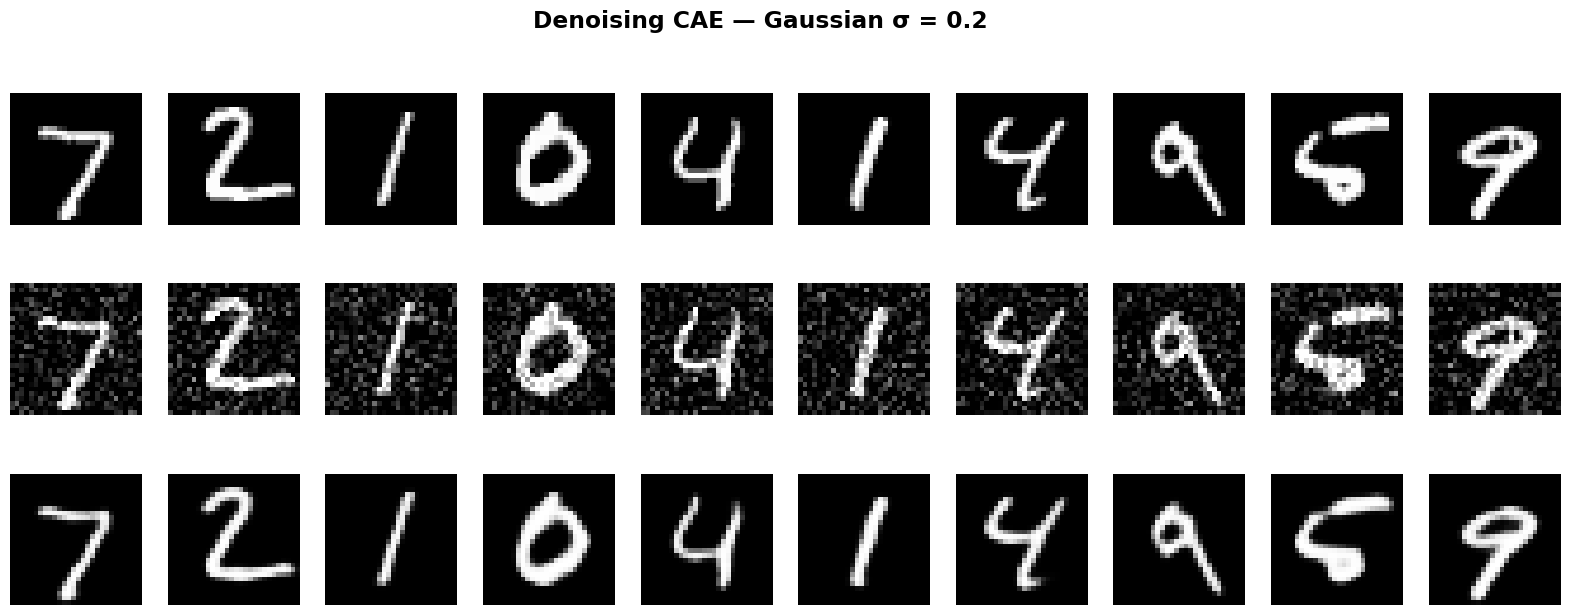

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/04_clean_noisy_denoised.eps')

In [ ]:
# ============================================================
# 6D. PLOT — CLEAN / NOISY / DENOISED
# ============================================================
noisy=gaussian_noise(x_test_img,0.2,500)
den=denoise_g.predict(noisy,batch_size=128,verbose=0)

fig,ax=plt.subplots(3,n,figsize=(20,7))
for i in range(n):
    ax[0,i].imshow(x_test[i],cmap="gray")
    ax[1,i].imshow(noisy[i].squeeze(),cmap="gray")
    ax[2,i].imshow(den[i].squeeze(),cmap="gray")
    for r in range(3): ax[r,i].axis("off")
ax[0,0].set_ylabel("Clean",fontweight="bold")
ax[1,0].set_ylabel("Noisy",fontweight="bold")
ax[2,0].set_ylabel("Denoised",fontweight="bold")
fig.suptitle("Denoising CAE — Gaussian σ = 0.2",fontweight="bold")
savefig(fig,"04_clean_noisy_denoised")

,Noise Type,Level,MSE,MAE,SSIM
0,Gaussian,0.1,0.002608,0.015477,0.968226
1,Gaussian,0.2,0.003673,0.018712,0.954060
2,Gaussian,0.3,0.005617,0.023899,0.926540


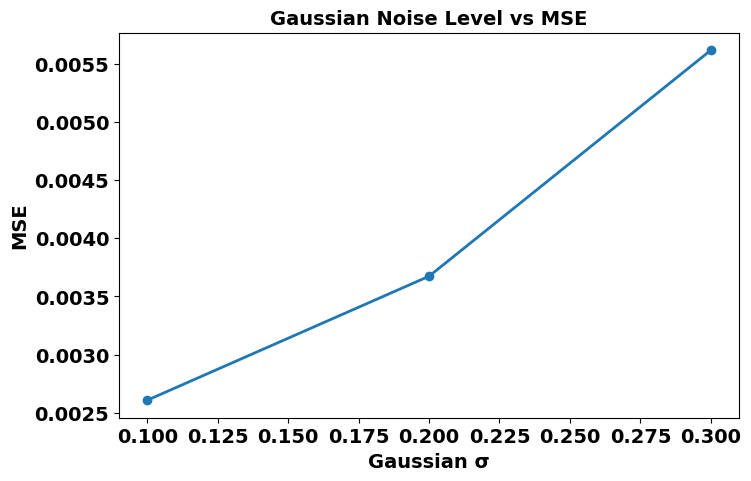

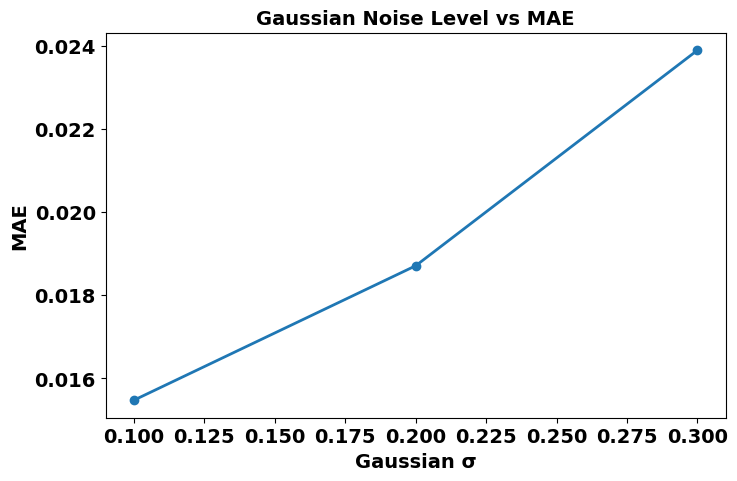

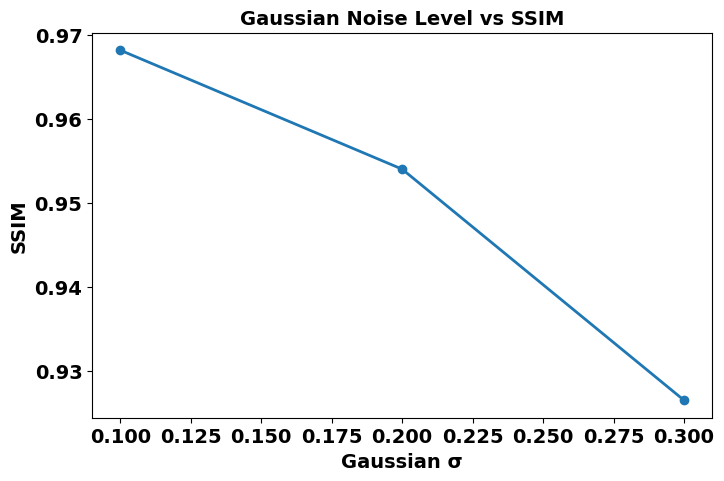

In [ ]:
# ============================================================
# 6E. REQUIRED NOISE-LEVEL METRICS
# ============================================================
gaussian_rows=[]
for s in G_LEVELS:
    pred=denoise_g.predict(gaussian_noise(x_test_img,s,500),batch_size=128,verbose=0)
    m=metrics_image(x_test_img,pred)
    gaussian_rows.append({"Noise Type":"Gaussian","Level":s,**m})
gaussian_df=pd.DataFrame(gaussian_rows)
gaussian_df.to_csv(TABLE_DIR/"gaussian_noise_metrics.csv",index=False)
display(gaussian_df)

for metric in ["MSE","MAE","SSIM"]:
    fig,ax=plt.subplots(figsize=(8,5))
    ax.plot(gaussian_df.Level,gaussian_df[metric],marker="o",linewidth=2)
    finish_axes(ax,f"Gaussian Noise Level vs {metric}","Gaussian σ",metric)
    savefig(fig,f"05_gaussian_{metric.lower()}")

In [ ]:
# ============================================================
# 6F. SALT-AND-PEPPER METRICS + DIRECT COMPARISON
# ============================================================
sp_rows=[]
for p in SP_LEVELS:
    pred=denoise_sp.predict(salt_pepper(x_test_img,p,600),batch_size=128,verbose=0)
    m=metrics_image(x_test_img,pred)
    sp_rows.append({"Noise Type":"Salt-and-Pepper","Level":p,**m})
sp_df=pd.DataFrame(sp_rows)
sp_df.to_csv(TABLE_DIR/"salt_pepper_metrics.csv",index=False)
display(sp_df)

comparison_noise=pd.concat([gaussian_df,sp_df],ignore_index=True)
comparison_noise.to_csv(TABLE_DIR/"noise_type_comparison.csv",index=False)
display(comparison_noise)

,Noise Type,Level,MSE,MAE,SSIM
0,Salt-and-Pepper,0.05,0.002882,0.015879,0.969445
1,Salt-and-Pepper,0.10,0.003533,0.017576,0.961389
2,Salt-and-Pepper,0.20,0.005555,0.022419,0.936122


,Noise Type,Level,MSE,MAE,SSIM
0,Gaussian,0.10,0.002608,0.015477,0.968226
1,Gaussian,0.20,0.003673,0.018712,0.954060
2,Gaussian,0.30,0.005617,0.023899,0.926540
3,Salt-and-Pepper,0.05,0.002882,0.015879,0.969445
4,Salt-and-Pepper,0.10,0.003533,0.017576,0.961389
5,Salt-and-Pepper,0.20,0.005555,0.022419,0.936122


In [ ]:
# ============================================================
# 6G. ADDITIONAL EXERCISE 3 — TWO NOISE LEVELS, SSIM COMPARISON
# ============================================================
# Explicitly compare two levels from each corruption family.
two_level_rows = comparison_noise[
    comparison_noise["Level"].isin([0.1,0.2,0.05,0.10])
].copy()
display(two_level_rows)

,Noise Type,Level,MSE,MAE,SSIM
0,Gaussian,0.10,0.002608,0.015477,0.968226
1,Gaussian,0.20,0.003673,0.018712,0.954060
3,Salt-and-Pepper,0.05,0.002882,0.015879,0.969445
4,Salt-and-Pepper,0.10,0.003533,0.017576,0.961389
5,Salt-and-Pepper,0.20,0.005555,0.022419,0.936122


# 7. VAE — 2-D LATENT SPACE

The sheet specifies a 2-D latent space, encoder outputs μ and log σ², and the reparameterization trick `z = μ + σ ⊙ ε`, with ε sampled from N(0,I). fileciteturn0file0L271-L317

In [ ]:
# ============================================================
# 7A. VAE FACTORY
# ============================================================
class Sampling(layers.Layer):
    def call(self,inputs):
        mu,logvar=inputs
        eps=tf.random.normal(tf.shape(mu))
        return mu+tf.exp(0.5*logvar)*eps

def build_vae(latent_dim=2):
    enc_in=layers.Input((28,28,1))
    x=layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(enc_in)
    x=layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
    x=layers.Flatten()(x)
    x=layers.Dense(128,activation="relu")(x)
    mu=layers.Dense(latent_dim,name="mu")(x)
    logvar=layers.Dense(latent_dim,name="logvar")(x)
    z=Sampling()([mu,logvar])
    enc=Model(enc_in,[mu,logvar,z],name=f"Encoder_z{latent_dim}")

    dec_in=layers.Input((latent_dim,))
    x=layers.Dense(7*7*64,activation="relu")(dec_in)
    x=layers.Reshape((7,7,64))(x)
    x=layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
    x=layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)
    out=layers.Conv2D(1,3,padding="same",activation="sigmoid")(x)
    dec=Model(dec_in,out,name=f"Decoder_z{latent_dim}")
    return enc,dec

# ============================================================
# CORRECTED VAE CLASS
# ============================================================

class VAE(tf.keras.Model):

    def __init__(self, enc, dec):
        super().__init__()

        self.enc = enc
        self.dec = dec

        self.t = tf.keras.metrics.Mean(name="loss")
        self.r = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.k = tf.keras.metrics.Mean(
            name="kl_loss"
        )

        self.beta = 1.0

    @property
    def metrics(self):
        return [
            self.t,
            self.r,
            self.k
        ]

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------
    def call(self, inputs, training=False):

        mu, logvar, z = self.enc(
            inputs,
            training=training
        )

        reconstruction = self.dec(
            z,
            training=training
        )

        return reconstruction

    # --------------------------------------------------------
    # Loss calculation
    # --------------------------------------------------------
    def calc(self, x, training=False):

        mu, logvar, z = self.enc(
            x,
            training=training
        )

        reconstruction = self.dec(
            z,
            training=training
        )

        # Reconstruction loss
        bce = tf.keras.backend.binary_crossentropy(
            x,
            reconstruction
        )

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                bce,
                axis=(1, 2)
            )
        )

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1
                + logvar
                - tf.square(mu)
                - tf.exp(logvar),
                axis=1
            )
        )

        # Total VAE objective
        total_loss = (
            reconstruction_loss
            + self.beta * kl_loss
        )

        return (
            total_loss,
            reconstruction_loss,
            kl_loss
        )

    # --------------------------------------------------------
    # Training step
    # --------------------------------------------------------
    def train_step(self, data):

        x = data[0] if isinstance(
            data,
            (tuple, list)
        ) else data

        with tf.GradientTape() as tape:

            total_loss, reconstruction_loss, kl_loss = (
                self.calc(
                    x,
                    training=True
                )
            )

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(
                gradients,
                self.trainable_weights
            )
        )

        self.t.update_state(total_loss)
        self.r.update_state(reconstruction_loss)
        self.k.update_state(kl_loss)

        return {
            "loss": self.t.result(),
            "reconstruction_loss": self.r.result(),
            "kl_loss": self.k.result()
        }

    # --------------------------------------------------------
    # Validation step
    # --------------------------------------------------------
    def test_step(self, data):

        x = data[0] if isinstance(
            data,
            (tuple, list)
        ) else data

        total_loss, reconstruction_loss, kl_loss = (
            self.calc(
                x,
                training=False
            )
        )

        self.t.update_state(total_loss)
        self.r.update_state(reconstruction_loss)
        self.k.update_state(kl_loss)

        return {
            "loss": self.t.result(),
            "reconstruction_loss": self.r.result(),
            "kl_loss": self.k.result()
        }
def train_vae(latent_dim=2, beta=1.0, epochs=30, name="vae"):

    # --------------------------------------------------------
    # Build encoder and decoder
    # --------------------------------------------------------
    enc, dec = build_vae(latent_dim)

    # Create custom VAE
    model = VAE(enc, dec)

    # Set KL-loss weight
    model.beta = beta

    # --------------------------------------------------------
    # IMPORTANT:
    # Explicitly build the outer VAE model before
    # ModelCheckpoint tries to save its weights.
    # --------------------------------------------------------
    dummy_input = tf.zeros(
        (1, 28, 28, 1),
        dtype=tf.float32
    )

    _ = model(
        dummy_input,
        training=False
    )

    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        )
    )

    # --------------------------------------------------------
    # Checkpoint path
    # --------------------------------------------------------
    path = CKPT_DIR / f"{name}_best.weights.h5"

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    t0 = time.time()

    hist = model.fit(
        x_train_img,
        validation_data=(x_val_img,),
        epochs=epochs,
        batch_size=128,

        callbacks=add_ckpt_callbacks(
            path,
            f"{name}.csv"
        ),

        verbose=1
    )

    elapsed = time.time() - t0

    # --------------------------------------------------------
    # Restore best validation-loss weights
    # --------------------------------------------------------
    if path.exists():
        model.load_weights(path)

    return model, hist, elapsed

In [ ]:
# ============================================================
# 7B. MAIN VAE — z = 2
# ============================================================
vae,vae_hist,vae_time=train_vae(2,1.0,30,"vae_z2_beta1")

mu_test,lv_test,z_test=vae.enc.predict(x_test_img,batch_size=128,verbose=0)
vae_pred=vae.dec.predict(z_test,batch_size=128,verbose=0)
vae_metrics=metrics_image(x_test_img,vae_pred)
vae_eval=vae.evaluate(x_test_img,batch_size=128,return_dict=True,verbose=0)

vae_summary={
    "Reconstruction Loss":float(vae_eval["reconstruction_loss"]),
    "KL Loss":float(vae_eval["kl_loss"]),
    "Total Loss":float(vae_eval["loss"]),
    "Test MSE":vae_metrics["MSE"],
    "Test MAE":vae_metrics["MAE"],
    "Mean SSIM":vae_metrics["SSIM"]
}
print(vae_summary)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - kl_loss: 3.4980 - loss: 417.1561 - reconstruction_loss: 413.6582
Epoch 1: val_loss improved from None to 213.77066, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/vae_z2_beta1_best.weights.h5

Epoch 1: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/vae_z2_beta1_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - kl_loss: 3.5226 - loss: 314.2442 - reconstruction_loss: 310.7216 - val_kl_loss: 3.6594 - val_loss: 213.7707 - val_reconstruction_loss: 210.1113
Epoch 2/30
59/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 3.0940 - loss: 207.5874 - reconstruction_loss: 204.4934
Epoch 2: val_loss improved from 213.77066 to 198.62726, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/vae_z2_beta1_best.weights.h5

Epoch 2: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/vae_z2_beta1_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s

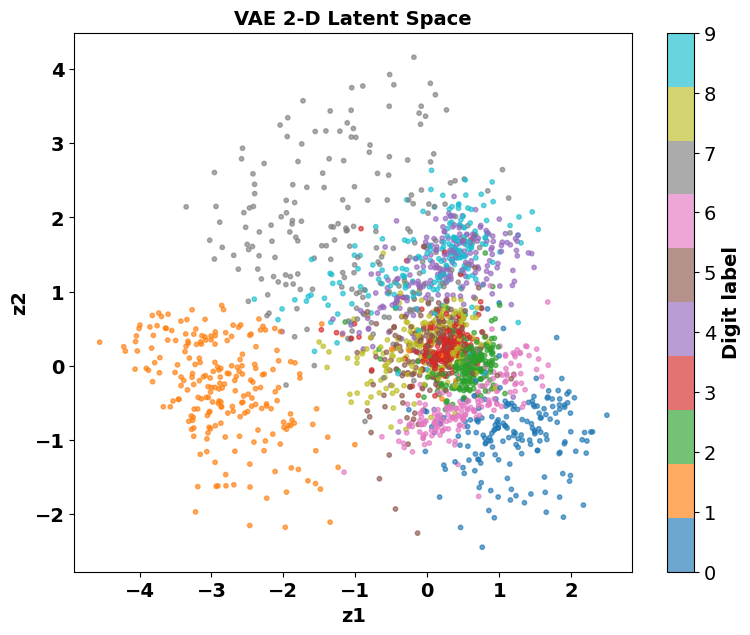

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/06_vae_latent_space.eps')

In [ ]:
# ============================================================
# 7C. VAE LATENT SPACE
# ============================================================
fig,ax=plt.subplots(figsize=(9,7))
sc=ax.scatter(mu_test[:,0],mu_test[:,1],c=y_test,s=10,alpha=.65,cmap="tab10")
finish_axes(ax,"VAE 2-D Latent Space","z1","z2")
cb=fig.colorbar(sc,ax=ax)
cb.set_label("Digit label",fontweight="bold",fontsize=14)
savefig(fig,"06_vae_latent_space")

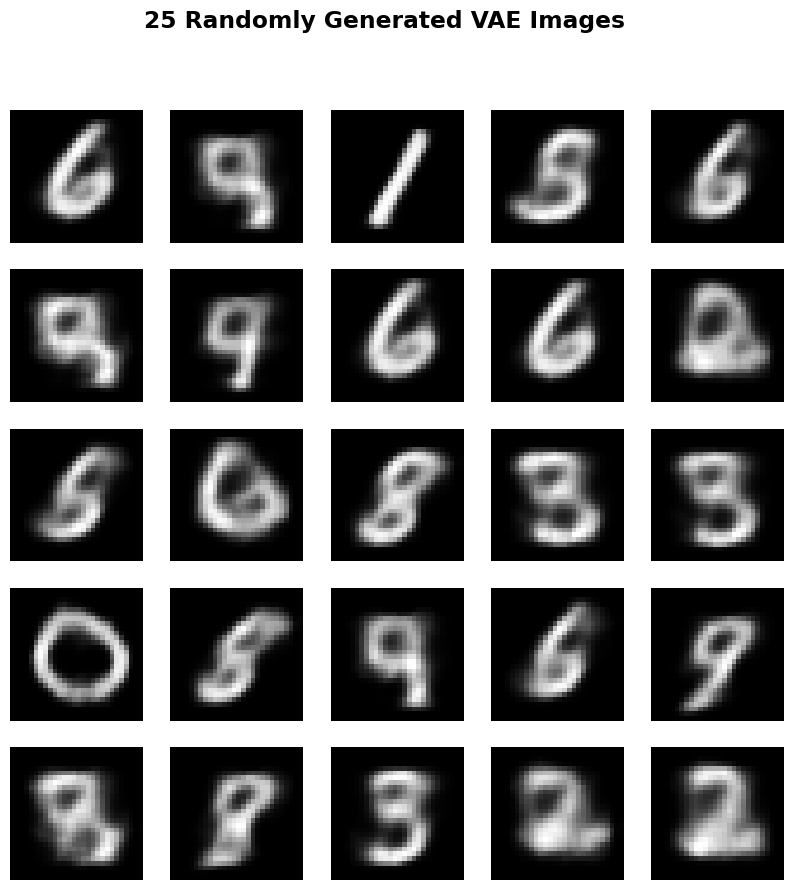

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/07_vae_25_generated.eps')

In [ ]:
# ============================================================
# 7D. 25 RANDOM GENERATED IMAGES
# ============================================================
rng=np.random.default_rng(SEED)
zrand=rng.normal(size=(25,2)).astype("float32")
gen25=vae.dec.predict(zrand,verbose=0)

fig,ax=plt.subplots(5,5,figsize=(10,10))
for i,a in enumerate(ax.flat):
    a.imshow(gen25[i].squeeze(),cmap="gray"); a.axis("off")
fig.suptitle("25 Randomly Generated VAE Images",fontweight="bold")
savefig(fig,"07_vae_25_generated")

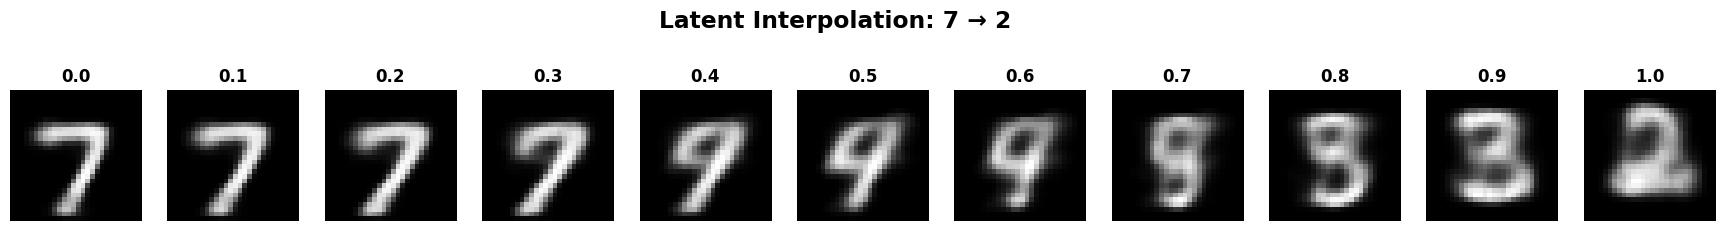

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/08_vae_latent_interpolation.eps')

In [ ]:
# ============================================================
# 7E. LATENT INTERPOLATION α = 0, .1, ..., 1
# ============================================================
a=0
b=next(i for i in range(1,len(y_test)) if y_test[i]!=y_test[a])
alphas=np.linspace(0,1,11)
zi=np.array([(1-q)*mu_test[a]+q*mu_test[b] for q in alphas],dtype="float32")
ii=vae.dec.predict(zi,verbose=0)

fig,ax=plt.subplots(1,11,figsize=(22,3))
for i,q in enumerate(alphas):
    ax[i].imshow(ii[i].squeeze(),cmap="gray")
    ax[i].set_title(f"{q:.1f}",fontweight="bold",fontsize=12)
    ax[i].axis("off")
fig.suptitle(f"Latent Interpolation: {y_test[a]} → {y_test[b]}",fontweight="bold")
savefig(fig,"08_vae_latent_interpolation")

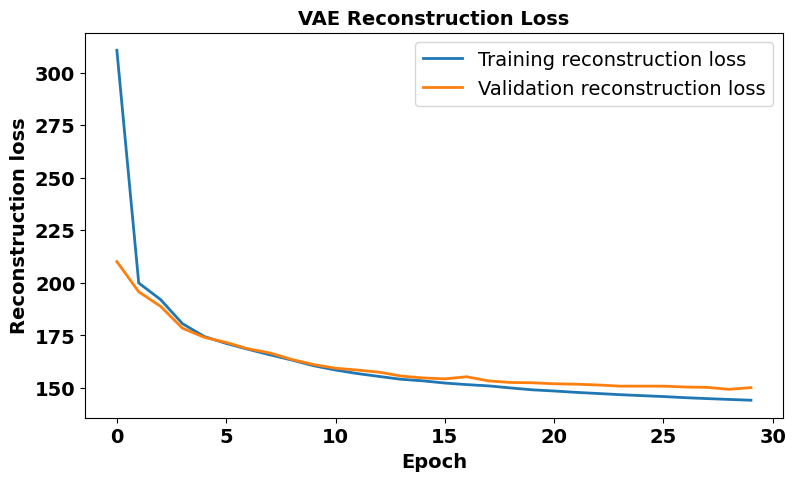

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/09_vae_reconstruction_loss.eps')

In [ ]:
# ============================================================
# 7F. VAE RECONSTRUCTION LOSS — NOT TOTAL LOSS
# ============================================================
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(vae_hist.history["reconstruction_loss"],label="Training reconstruction loss",linewidth=2)
ax.plot(vae_hist.history["val_reconstruction_loss"],label="Validation reconstruction loss",linewidth=2)
finish_axes(ax,"VAE Reconstruction Loss","Epoch","Reconstruction loss")
ax.legend()
savefig(fig,"09_vae_reconstruction_loss")

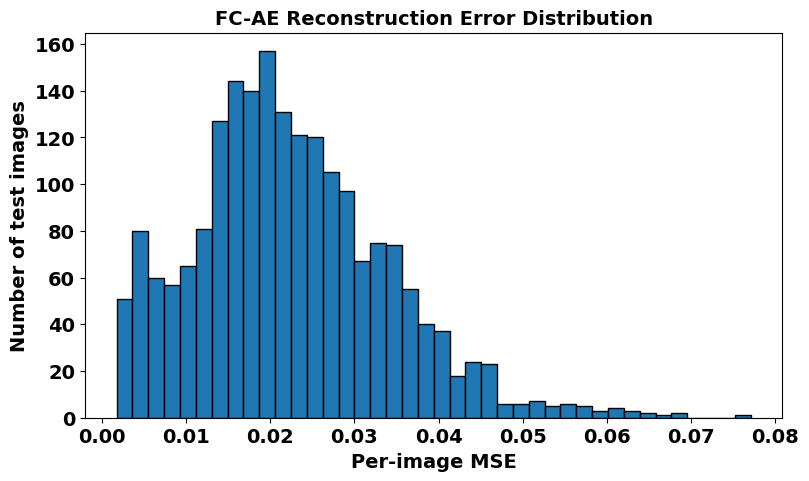

,Rank,Test index,Digit,MSE
0,1,1782,8,0.077072
1,2,1325,8,0.069419
2,3,1128,3,0.068032
3,4,1017,6,0.067193
4,5,338,8,0.065064


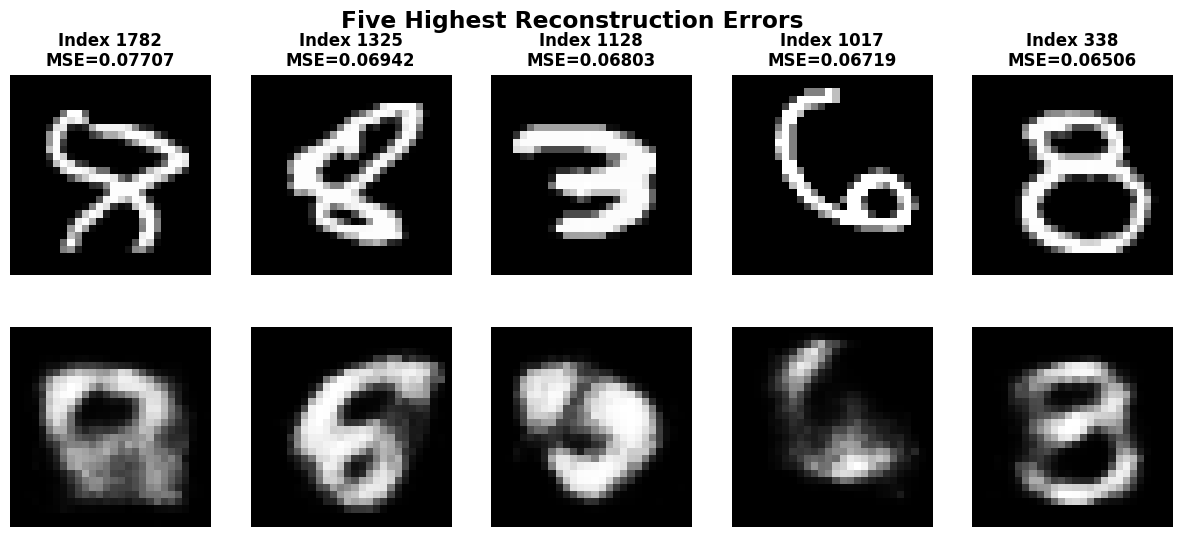

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/11_top5_high_error.eps')

In [ ]:
# ============================================================
# 8. RECONSTRUCTION ERROR DISTRIBUTION + TOP 5
# ============================================================
err=image_errors(x_test_img,fc_pred)

fig,ax=plt.subplots(figsize=(9,5))
ax.hist(err,bins=40,edgecolor="black")
finish_axes(ax,"FC-AE Reconstruction Error Distribution","Per-image MSE","Number of test images")
savefig(fig,"10_reconstruction_error_distribution")

top5=np.argsort(err)[-5:][::-1]
top5_table=pd.DataFrame({
    "Rank":range(1,6),
    "Test index":top5,
    "Digit":y_test[top5],
    "MSE":err[top5]
})
display(top5_table)
top5_table.to_csv(TABLE_DIR/"top5_high_error.csv",index=False)

fig,ax=plt.subplots(2,5,figsize=(15,6))
for j,i in enumerate(top5):
    ax[0,j].imshow(x_test[i],cmap="gray")
    ax[1,j].imshow(fc_pred[i].squeeze(),cmap="gray")
    ax[0,j].set_title(f"Index {i}\nMSE={err[i]:.5f}",fontweight="bold",fontsize=12)
    ax[0,j].axis("off"); ax[1,j].axis("off")
ax[0,0].set_ylabel("Original",fontweight="bold")
ax[1,0].set_ylabel("Reconstruction",fontweight="bold")
fig.suptitle("Five Highest Reconstruction Errors",fontweight="bold")
savefig(fig,"11_top5_high_error")

# 9. MANDATORY LATENT-DIMENSION STUDY — FC-AE

The source asks for `dz ∈ {2, 8, 16, 32}` and MSE, SSIM and parameter count. fileciteturn0file0L459-L471

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4989
Epoch 1: val_loss improved from None to 0.27045, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_latent_2.weights.h5

Epoch 1: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_latent_2.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.3701 - val_loss: 0.2704
Epoch 2/20
59/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2655
Epoch 2: val_loss improved from 0.27045 to 0.26344, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_latent_2.weights.h5

Epoch 2: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_latent_2.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2633 - val_loss: 0.2634
Epoch 3/20
58/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2600
Epoch 3: val_loss improved from 0.26344 to 0.26065, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/fc_latent_2.we

,Latent Dimension,MSE,SSIM,Parameters,Time (s)
0,2,0.057100,0.303824,210130,12.134735
1,8,0.033302,0.623377,210520,12.616521
2,16,0.024675,0.705872,211040,11.460443
3,32,0.021498,0.743559,212080,12.000365


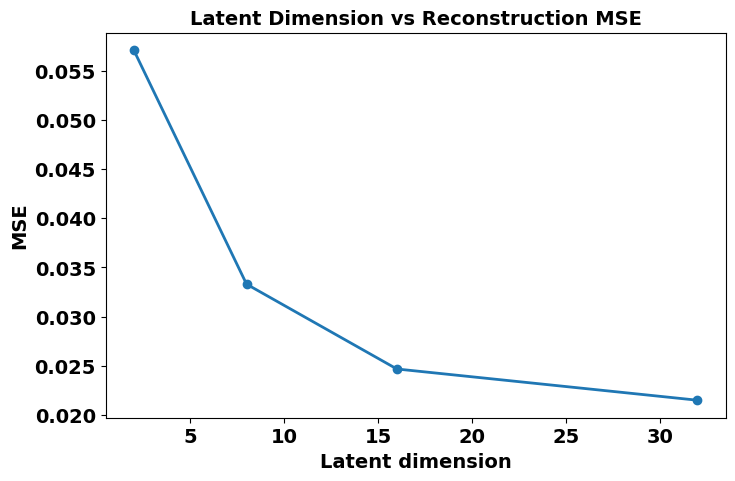

PosixPath('/content/Experiment_7_Autoencoders_COMPLETE/plots_eps_600dpi/12_latent_dimension_vs_mse.eps')

In [ ]:
# ============================================================
# 9A. FC-AE LATENT DIMENSIONS 2, 8, 16, 32
# ============================================================
fc_latent_rows=[]
for dz in [2,8,16,32]:
    clean_memory()
    model=build_fc_ae(dz)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss="binary_crossentropy")
    path=CKPT_DIR/f"fc_latent_{dz}.weights.h5"
    t0=time.time()
    h=model.fit(
        x_train_flat,x_train_flat,
        validation_data=(x_val_flat,x_val_flat),
        epochs=20,batch_size=128,
        callbacks=add_ckpt_callbacks(path,f"fc_latent_{dz}.csv"),
        verbose=1
    )
    elapsed=time.time()-t0
    model.load_weights(path)
    pred=model.predict(x_test_flat,batch_size=128,verbose=0).reshape(-1,28,28,1)
    m=metrics_image(x_test_img,pred)
    fc_latent_rows.append({
        "Latent Dimension":dz,
        "MSE":m["MSE"],
        "SSIM":m["SSIM"],
        "Parameters":model.count_params(),
        "Time (s)":elapsed
    })
    del model,pred,h
    gc.collect()

fc_latent_df=pd.DataFrame(fc_latent_rows)
display(fc_latent_df)
fc_latent_df.to_csv(TABLE_DIR/"mandatory_fc_latent_dimension.csv",index=False)

fig,ax=plt.subplots(figsize=(8,5))
ax.plot(fc_latent_df["Latent Dimension"],fc_latent_df["MSE"],marker="o",linewidth=2)
finish_axes(ax,"Latent Dimension vs Reconstruction MSE","Latent dimension","MSE")
savefig(fig,"12_latent_dimension_vs_mse")

# 10. ADDITIONAL EXERCISE 1 — CAE LATENT DIMENSIONS 4, 8, 16, 32

The source specifically asks to train the convolutional autoencoder with latent dimensions 4, 8, 16 and 32. For a CAE, the latent dimension is implemented as a compact bottleneck vector before decoding.

In [ ]:
# ============================================================
# 10A. CAE BOTTLENECK-DIMENSION STUDY
# Latent dimensions: 4, 8, 16, 32
# ============================================================

def build_cae_latent(latent_dim=16):

    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------
    inp = layers.Input(
        shape=(28, 28, 1),
        name="cae_input"
    )

    # --------------------------------------------------------
    # ENCODER
    # --------------------------------------------------------

    # 28 x 28 x 1
    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same",
        name="enc_conv1"
    )(inp)

    # 28 x 28 x 32 -> 14 x 14 x 32
    x = layers.MaxPooling2D(
        2,
        padding="same",
        name="enc_pool1"
    )(x)

    # 14 x 14 x 32 -> 14 x 14 x 64
    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same",
        name="enc_conv2"
    )(x)

    # 14 x 14 x 64 -> 7 x 7 x 64
    x = layers.MaxPooling2D(
        2,
        padding="same",
        name="enc_pool2"
    )(x)

    # 7 x 7 x 64
    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same",
        name="enc_conv3"
    )(x)

    # --------------------------------------------------------
    # SAVE THE FEATURE-MAP SHAPE
    # --------------------------------------------------------
    # Expected shape:
    # (7, 7, 64)
    feature_shape = x.shape[1:]

    # Convert:
    # 7 x 7 x 64 -> 3136
    x = layers.Flatten(
        name="flatten"
    )(x)

    # --------------------------------------------------------
    # BOTTLENECK / LATENT REPRESENTATION
    # --------------------------------------------------------
    # 3136 -> latent_dim
    z = layers.Dense(
        latent_dim,
        activation="relu",
        name=f"latent_{latent_dim}"
    )(x)

    # --------------------------------------------------------
    # DECODER
    # --------------------------------------------------------

    # latent_dim -> 3136
    x = layers.Dense(
        int(np.prod(feature_shape)),
        activation="relu",
        name="decoder_dense"
    )(z)

    # 3136 -> 7 x 7 x 64
    x = layers.Reshape(
        tuple(feature_shape),
        name="decoder_reshape"
    )(x)

    # 7 x 7 x 64 -> 14 x 14 x 64
    x = layers.UpSampling2D(
        2,
        name="dec_upsample1"
    )(x)

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same",
        name="dec_conv1"
    )(x)

    # 14 x 14 x 32 -> 28 x 28 x 32
    x = layers.UpSampling2D(
        2,
        name="dec_upsample2"
    )(x)

    # 28 x 28 x 32 -> 28 x 28 x 1
    out = layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same",
        name="decoder_output"
    )(x)

    # --------------------------------------------------------
    # COMPLETE CAE
    # --------------------------------------------------------
    model = Model(
        inp,
        out,
        name=f"CAE_z{latent_dim}"
    )

    return model


# ============================================================
# 10B. TRAIN CAE WITH DIFFERENT LATENT DIMENSIONS
# ============================================================

cae_latent_rows = []

latent_dimensions = [4, 8, 16, 32]

for dz in latent_dimensions:

    print("\n" + "=" * 65)
    print(f"TRAINING CAE WITH LATENT DIMENSION = {dz}")
    print("=" * 65)

    # --------------------------------------------------------
    # Clear memory from previous model
    # --------------------------------------------------------
    clean_memory()

    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------
    model = build_cae_latent(dz)

    # Display architecture
    print(f"\nModel: CAE_z{dz}")
    print(f"Latent dimension: {dz}")
    print(f"Trainable parameters: {model.count_params():,}")

    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy"
    )

    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------
    path = CKPT_DIR / f"cae_latent_{dz}_best.weights.h5"

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    t0 = time.time()

    h = model.fit(
        x_train_img,
        x_train_img,

        validation_data=(
            x_val_img,
            x_val_img
        ),

        epochs=20,
        batch_size=128,

        callbacks=add_ckpt_callbacks(
            path,
            f"cae_latent_{dz}.csv"
        ),

        verbose=1
    )

    elapsed = time.time() - t0

    # --------------------------------------------------------
    # Load best checkpoint
    # --------------------------------------------------------
    if path.exists():
        model.load_weights(path)
        print(f"Best weights loaded for latent dimension {dz}")

    # --------------------------------------------------------
    # Test reconstruction
    # --------------------------------------------------------
    pred = model.predict(
        x_test_img,
        batch_size=128,
        verbose=0
    )

    # --------------------------------------------------------
    # Calculate MSE, MAE and SSIM
    # --------------------------------------------------------
    m = metrics_image(
        x_test_img,
        pred
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    cae_latent_rows.append({
        "Latent Dimension": dz,
        "MSE": m["MSE"],
        "MAE": m["MAE"],
        "SSIM": m["SSIM"],
        "Parameters": model.count_params(),
        "Time (s)": elapsed
    })

    print("\nResults:")
    print(f"MSE        : {m['MSE']:.6f}")
    print(f"MAE        : {m['MAE']:.6f}")
    print(f"SSIM       : {m['SSIM']:.6f}")
    print(f"Parameters : {model.count_params():,}")
    print(f"Time       : {elapsed:.2f} seconds")

    # --------------------------------------------------------
    # Free memory before next latent dimension
    # --------------------------------------------------------
    del model
    del pred
    del h

    gc.collect()


# ============================================================
# 10C. CREATE RESULTS TABLE
# ============================================================

cae_latent_df = pd.DataFrame(
    cae_latent_rows
)

display(cae_latent_df)


# ============================================================
# 10D. SAVE RESULTS
# ============================================================

cae_latent_df.to_csv(
    TABLE_DIR / "additional_01_cae_latent_dimensions.csv",
    index=False
)

print(
    "\nSaved:"
    f"\n{TABLE_DIR / 'additional_01_cae_latent_dimensions.csv'}"
)


TRAINING CAE WITH LATENT DIMENSION = 4

Model: CAE_z4
Latent dimension: 4
Trainable parameters: 102,725
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4626
Epoch 1: val_loss improved from None to 0.26667, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_latent_4_best.weights.h5

Epoch 1: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_latent_4_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.3479 - val_loss: 0.2667
Epoch 2/20
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2598
Epoch 2: val_loss improved from 0.26667 to 0.24989, saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_latent_4_best.weights.h5

Epoch 2: finished saving model to /content/Experiment_7_Autoencoders_COMPLETE/checkpoints/cae_latent_4_best.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2555 - val_loss: 0.2499
Epoch 3/20
60/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2442
Epoch 3:

,Latent Dimension,MSE,MAE,SSIM,Parameters,Time (s)
0,4,0.047822,0.107770,0.449029,102725,21.171094
1,8,0.027910,0.068708,0.698400,127817,19.951794
2,16,0.040034,0.093546,0.549730,178001,20.479933
3,32,0.011560,0.036149,0.875795,278369,21.247200



Saved:
/content/Experiment_7_Autoencoders_COMPLETE/tables/additional_01_cae_latent_dimensions.csv


# 11. ADDITIONAL EXERCISE 2 — GAUSSIAN VS SALT-AND-PEPPER

Both denoisers use the same CAE architecture, optimizer, learning rate, batch size and epoch budget. This isolates the effect of corruption type.

In [ ]:
# ============================================================
# 11A. SAME-ARCHITECTURE NOISE COMPARISON
# ============================================================
noise_compare=pd.concat([
    gaussian_df.assign(Level_label=gaussian_df["Level"].astype(str)),
    sp_df.assign(Level_label=sp_df["Level"].astype(str))
],ignore_index=True)

display(noise_compare)
noise_compare.to_csv(TABLE_DIR/"additional_02_noise_type_comparison.csv",index=False)

# Separate figures because MSE, MAE and SSIM have different scales.
for metric in ["MSE","MAE","SSIM"]:
    fig,ax=plt.subplots(figsize=(9,5))
    ax.plot(gaussian_df.Level,gaussian_df[metric],marker="o",label="Gaussian")
    ax.plot(sp_df.Level,sp_df[metric],marker="s",label="Salt-and-pepper")
    finish_axes(ax,f"Noise Type Comparison — {metric}","Corruption level",metric)
    ax.legend()
    savefig(fig,f"13_noise_type_{metric.lower()}")

# 12. ADDITIONAL EXERCISE 3 — TWO DENOISING LEVELS AND SSIM

The source asks for two different noise levels and a comparison of SSIM. The following explicitly records both low/high examples for each corruption family.

In [ ]:
# ============================================================
# 12A. TWO-LEVEL SSIM STUDY
# ============================================================
two_level_ssim=pd.DataFrame([
    {"Noise type":"Gaussian","Level":0.1,
     "SSIM":float(gaussian_df.loc[gaussian_df.Level==0.1,"SSIM"].iloc[0])},
    {"Noise type":"Gaussian","Level":0.3,
     "SSIM":float(gaussian_df.loc[gaussian_df.Level==0.3,"SSIM"].iloc[0])},
    {"Noise type":"Salt-and-pepper","Level":0.05,
     "SSIM":float(sp_df.loc[sp_df.Level==0.05,"SSIM"].iloc[0])},
    {"Noise type":"Salt-and-pepper","Level":0.20,
     "SSIM":float(sp_df.loc[sp_df.Level==0.20,"SSIM"].iloc[0])}
])
display(two_level_ssim)
two_level_ssim.to_csv(TABLE_DIR/"additional_03_two_noise_levels_ssim.csv",index=False)

# 13. ADDITIONAL EXERCISE 4 — UpSampling VS TRANSPOSED-CONVOLUTION DECODER

The mandatory CAE permits either UpSampling2D or Conv2DTranspose. This additional experiment trains both versions with the same encoder-side structure and compares reconstruction quality.

In [ ]:
# ============================================================
# 13A. TRANSPOSED-CONVOLUTION CAE
# ============================================================
cae_t=build_cae(True)
cae_t.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss="binary_crossentropy")
p=CKPT_DIR/"cae_transpose_best.weights.h5"
t0=time.time()
ht=cae_t.fit(
    x_train_img,x_train_img,
    validation_data=(x_val_img,x_val_img),
    epochs=20,batch_size=128,
    callbacks=add_ckpt_callbacks(p,"cae_transpose.csv"),
    verbose=1
)
t_time=time.time()-t0
cae_t.load_weights(p)
pred_t=cae_t.predict(x_test_img,batch_size=128,verbose=0)
transpose_metrics=metrics_image(x_test_img,pred_t)

decoder_compare=pd.DataFrame([
    {"Decoder":"UpSampling2D + Conv2D",**cae_metrics,"Parameters":cae.count_params(),"Time (s)":cae_time},
    {"Decoder":"Conv2DTranspose",**transpose_metrics,"Parameters":cae_t.count_params(),"Time (s)":t_time}
])
display(decoder_compare)
decoder_compare.to_csv(TABLE_DIR/"additional_04_decoder_comparison.csv",index=False)

# 14. ADDITIONAL EXERCISE 5 — VAE LATENT DIMENSION 2 VS 8

In [ ]:
# ============================================================
# 14A. VAE z=2 VS z=8
# ============================================================
vae_dim_rows=[]
vae_models={}

for dz in [2,8]:
    clean_memory()
    model,h,elapsed=train_vae(dz,1.0,30,f"additional_05_vae_z{dz}")
    mu,lv,z=model.enc.predict(x_test_img,batch_size=128,verbose=0)
    pred=model.dec.predict(z,batch_size=128,verbose=0)
    m=metrics_image(x_test_img,pred)
    ev=model.evaluate(x_test_img,batch_size=128,return_dict=True,verbose=0)
    vae_dim_rows.append({
        "Latent Dimension":dz,
        "MSE":m["MSE"],"MAE":m["MAE"],"SSIM":m["SSIM"],
        "Reconstruction Loss":float(ev["reconstruction_loss"]),
        "KL Loss":float(ev["kl_loss"]),
        "Total Loss":float(ev["loss"]),
        "Parameters":model.count_params(),
        "Time (s)":elapsed
    })
    if dz==8:
        vae_models["z8"]=(model,mu,lv,z,pred)
    else:
        vae_models["z2"]=(model,mu,lv,z,pred)

vae_dim_df=pd.DataFrame(vae_dim_rows)
display(vae_dim_df)
vae_dim_df.to_csv(TABLE_DIR/"additional_05_vae_latent_2_vs_8.csv",index=False)

# 15. ADDITIONAL EXERCISE 6 — EFFECT OF KL-LOSS CONTRIBUTION

The VAE objective becomes `L = Lrec + βLKL`. We keep the architecture and optimizer fixed and vary β. This directly studies how strongly the latent distribution is regularized.

In [ ]:
# ============================================================
# 15A. KL BETA STUDY
# ============================================================
beta_rows=[]
for beta in [0.0,0.5,1.0,2.0]:
    clean_memory()
    model,h,elapsed=train_vae(2,beta,20,f"additional_06_beta_{str(beta).replace('.','_')}")
    mu,lv,z=model.enc.predict(x_test_img,batch_size=128,verbose=0)
    pred=model.dec.predict(z,batch_size=128,verbose=0)
    m=metrics_image(x_test_img,pred)
    ev=model.evaluate(x_test_img,batch_size=128,return_dict=True,verbose=0)
    beta_rows.append({
        "Beta":beta,
        "MSE":m["MSE"],"MAE":m["MAE"],"SSIM":m["SSIM"],
        "Reconstruction Loss":float(ev["reconstruction_loss"]),
        "KL Loss":float(ev["kl_loss"]),
        "Total Loss":float(ev["loss"]),
        "Time (s)":elapsed
    })
    del model,h,mu,lv,z,pred
    gc.collect()

beta_df=pd.DataFrame(beta_rows)
display(beta_df)
beta_df.to_csv(TABLE_DIR/"additional_06_kl_beta_study.csv",index=False)

fig,ax=plt.subplots(figsize=(8,5))
ax.plot(beta_df.Beta,beta_df["KL Loss"],marker="o",label="KL loss")
finish_axes(ax,"KL Contribution vs β","β","KL loss")
ax.legend()
savefig(fig,"14_beta_vs_kl_loss")

fig,ax=plt.subplots(figsize=(8,5))
ax.plot(beta_df.Beta,beta_df["Reconstruction Loss"],marker="o",label="Reconstruction loss")
finish_axes(ax,"Reconstruction Loss vs β","β","Reconstruction loss")
ax.legend()
savefig(fig,"15_beta_vs_reconstruction_loss")

# 16. ADDITIONAL EXERCISE 7 — LARGER VAE SAMPLE GRID

In [ ]:
# ============================================================
# 16A. 100 GENERATED SAMPLES
# ============================================================
# Use the already trained main z=2 VAE.
z100=np.random.default_rng(123).normal(size=(100,2)).astype("float32")
gen100=vae.dec.predict(z100,batch_size=100,verbose=0)

fig,ax=plt.subplots(10,10,figsize=(15,15))
for i,a in enumerate(ax.flat):
    a.imshow(gen100[i].squeeze(),cmap="gray")
    a.axis("off")
fig.suptitle("VAE — 100 Randomly Generated Samples",fontweight="bold")
savefig(fig,"16_vae_100_generated")

# 17. ADDITIONAL EXERCISE 8 — LATENT-REGION INTERPOLATION

Instead of only choosing arbitrary endpoints, this study uses latent points from two digit regions and decodes a sequence between their mean latent locations.

In [ ]:
# ============================================================
# 17A. DIGIT-REGION INTERPOLATION
# ============================================================
digit_a=1
digit_b=7
za=mu_test[y_test==digit_a].mean(axis=0)
zb=mu_test[y_test==digit_b].mean(axis=0)

alphas=np.linspace(0,1,11)
region_z=np.array([(1-a)*za+a*zb for a in alphas],dtype="float32")
region_imgs=vae.dec.predict(region_z,batch_size=11,verbose=0)

fig,ax=plt.subplots(1,11,figsize=(22,3))
for i,a in enumerate(alphas):
    ax[i].imshow(region_imgs[i].squeeze(),cmap="gray")
    ax[i].set_title(f"{a:.1f}",fontweight="bold",fontsize=12)
    ax[i].axis("off")
fig.suptitle(f"Latent-Region Interpolation: digit {digit_a} region → digit {digit_b} region",
             fontweight="bold")
savefig(fig,"17_latent_region_interpolation")

# 18. CONSOLIDATED MANDATORY MODEL RESULTS

In [ ]:
# ============================================================
# 18A. CONSOLIDATED TABLE
# ============================================================
# Denoising entry uses Gaussian σ=0.2 as the required representative level.
den_row=gaussian_df[gaussian_df.Level==0.2].iloc[0]

consolidated=pd.DataFrame([
    {"Model":"FC Autoencoder","MSE":fc_metrics["MSE"],"MAE":fc_metrics["MAE"],
     "SSIM":fc_metrics["SSIM"],"Parameters":fc_ae.count_params(),"Time (s)":fc_time},
    {"Model":"Convolutional Autoencoder","MSE":cae_metrics["MSE"],"MAE":cae_metrics["MAE"],
     "SSIM":cae_metrics["SSIM"],"Parameters":cae.count_params(),"Time (s)":cae_time},
    {"Model":"Denoising CAE (Gaussian σ=0.2)","MSE":den_row.MSE,"MAE":den_row.MAE,
     "SSIM":den_row.SSIM,"Parameters":denoise_g.count_params(),"Time (s)":g_time},
    {"Model":"VAE (z=2)","MSE":vae_metrics["MSE"],"MAE":vae_metrics["MAE"],
     "SSIM":vae_metrics["SSIM"],"Parameters":vae.count_params(),"Time (s)":vae_time}
])
display(consolidated)
consolidated.to_csv(TABLE_DIR/"consolidated_results.csv",index=False)

pd.DataFrame([vae_summary]).to_csv(TABLE_DIR/"vae_loss_components.csv",index=False)

# 19. REQUIRED HUMANIZED INFERENCE NOTES

The report must answer, for every major plot:

1. What does the plot show?
2. What trend is observed?
3. Why might that trend occur?
4. What conclusion can be drawn?

The notebook below prints the measured evidence. The written interpretation should describe the actual images and values you obtain rather than copying a predetermined conclusion. fileciteturn0file0L442-L458

In [ ]:
# ============================================================
# 19A. EVIDENCE FOR REPORT WRITING
# ============================================================
print("FC-AE:",fc_metrics)
print("CAE :",cae_metrics)
print("\nGaussian noise:")
display(gaussian_df)
print("\nSalt-and-pepper:")
display(sp_df)
print("\nFC latent study:")
display(fc_latent_df)
print("\nCAE latent study:")
display(cae_latent_df)
print("\nVAE z=2 vs z=8:")
display(vae_dim_df)
print("\nKL beta study:")
display(beta_df)
print("\nDecoder comparison:")
display(decoder_compare)
print("\nTop 5 high-error samples:")
display(top5_table)

# 20. FINAL REQUIREMENT AUDIT

This cell checks that the principal required artifacts and additional-exercise tables exist before submission.

In [ ]:
# ============================================================
# 20A. FINAL AUDIT
# ============================================================
required_files = [
    "01_fc_original_reconstruction.eps",
    "02_fc_training_validation_loss.eps",
    "03_fc_vs_cae.eps",
    "04_clean_noisy_denoised.eps",
    "05_gaussian_mse.eps",
    "05_gaussian_mae.eps",
    "05_gaussian_ssim.eps",
    "06_vae_latent_space.eps",
    "07_vae_25_generated.eps",
    "08_vae_latent_interpolation.eps",
    "09_vae_reconstruction_loss.eps",
    "10_reconstruction_error_distribution.eps",
    "11_top5_high_error.eps",
    "12_latent_dimension_vs_mse.eps",
    "16_vae_100_generated.eps",
    "17_latent_region_interpolation.eps"
]

required_tables = [
    "gaussian_noise_metrics.csv",
    "salt_pepper_metrics.csv",
    "noise_type_comparison.csv",
    "additional_03_two_noise_levels_ssim.csv",
    "additional_04_decoder_comparison.csv",
    "additional_05_vae_latent_2_vs_8.csv",
    "additional_06_kl_beta_study.csv",
    "mandatory_fc_latent_dimension.csv",
    "additional_01_cae_latent_dimensions.csv",
    "consolidated_results.csv",
    "vae_loss_components.csv",
    "top5_high_error.csv"
]

missing_figs=[f for f in required_files if not (EPS_DIR/f).exists()]
missing_tables=[f for f in required_tables if not (TABLE_DIR/f).exists()]

print("EPS figures required:",len(required_files))
print("Missing EPS:",missing_figs)
print("Required tables:",len(required_tables))
print("Missing tables:",missing_tables)

if not missing_figs and not missing_tables:
    print("\nAUDIT PASSED: principal required outputs and additional-exercise tables are present.")
else:
    print("\nAUDIT INCOMPLETE: run the missing sections shown above.")

# 21. DISCUSSION QUESTIONS

Answer these in your own words after inspecting your actual results:

1. What is an autoencoder?
2. What is the purpose of the encoder?
3. What is the purpose of the decoder?
4. What is a latent representation?
5. Why is the latent representation usually smaller than the input?
6. What happens when the latent dimension is too small?
7. What happens when the latent dimension is increased?
8. Why can a convolutional autoencoder preserve spatial information more effectively?
9. Differentiate an autoencoder and a denoising autoencoder.
10. Why is the clean image used as the target in denoising?
11. What happens when the noise level is increased?
12. Why are MSE, MAE and SSIM useful for image reconstruction?
13. What is a Variational Autoencoder?
14. How does a VAE differ from a conventional autoencoder?
15. Why does a VAE learn a distribution instead of a single latent vector?
16. What is the reparameterization trick?
17. Why is ε sampled from a standard normal distribution?
18. What is the role of KL divergence in the VAE loss?
19. What is the prior distribution used in the VAE?
20. Why is a two-dimensional latent space useful for visualization?
21. What does latent-space interpolation demonstrate?
22. Why can a VAE generate new images?
23. Why might some VAE-generated images be unclear?
24. What is the difference between reconstruction and generation?
25. Why should test images remain unseen during training?

These are the discussion questions specified in the source. fileciteturn0file0L472-L497

# 22. SUBMISSION CHECKLIST

Before submitting the report:

- [ ] All mandatory models trained.
- [ ] Test set remained unseen during fitting.
- [ ] All mandatory plots exported as EPS.
- [ ] EPS resolution set to 600 DPI.
- [ ] Times New Roman 14 pt verified in Colab.
- [ ] X/Y labels and legends bold.
- [ ] MSE, MAE and SSIM reported.
- [ ] VAE reconstruction, KL and total losses reported.
- [ ] 25 generated samples included.
- [ ] Top 5 high-error samples discussed.
- [ ] FC latent study 2/8/16/32 completed.
- [ ] All eight additional exercises completed.
- [ ] Actual numerical values copied from generated CSVs.
- [ ] Interpretations refer to actual plots/images.
- [ ] No invented performance values.
- [ ] Final audit cell passes.

The source states that numerical performance values must come from the student's own execution and that the final report should include both quantitative and visual analysis. fileciteturn0file0L507-L518